# Hito 2: Análisis de Canciones de Spotify
**Grupo 17 - Minería de Datos (CC5205)**

**Integrantes:**
* Juan Balboa E.
* Sebastián Cadena A.
* Benjamín Fuentes R.
* Matías Méndez Z.
* Camila Rojas G.

## 1. Introducción y Motivación

Spotify es una de las plataformas de música más importantes del mundo, con más de 100 millones de canciones. Este proyecto busca aprovechar esta enorme cantidad de información para entender la música desde una perspectiva de minería de datos. Cada canción posee características objetivas de audio extraídas por Spotify (como *danceability*, *energy*, *valence*), además de metadatos sobre artistas y géneros.

**El problema principal:** La industria musical es altamente competitiva. Entender qué hace que una canción sea popular o cómo se agrupan naturalmente los géneros más allá de las etiquetas tradicionales puede ofrecer un valor inmenso para artistas y discográficas.

### Preguntas de Investigación:
1.  ¿Es posible predecir la popularidad de una canción basándose únicamente en sus características de audio y el artista?
2.  ¿Existen grupos naturales de canciones que compartan características similares, independientemente de su género declarado?
3.   ¿Es posible predecir el género de una canción a partir de sus características de audio como energía, tempo o bailabilidad?

## 2. Síntesis Hito 1

En la primera etapa del proyecto, se analizó un conjunto de datos de 114.000 canciones de Spotify con el objetivo de predecir la popularidad de las canciones. El Análisis Exploratorio de Datos (EDA) reveló que las características acústicas individuales (como danceability, energy o tempo) poseen una correlación lineal muy baja con la popularidad, sugiriendo la necesidad de modelos no lineales.

### 2.1 Resultados Experimentales Preliminares

Se realizaron pruebas de concepto para la predicción de popularidad bajo dos enfoques:

- **Regresión**: Se contrastó una Regresión Lineal ($R^2$: 0.26) contra un Random Forest Regressor ($R^2$: 0.52). Este último demostró una capacidad predictiva superior, reduciendo el MAE de 14.07 a 10.40, confirmando que la complejidad de los datos requiere modelos basados en árboles o ensambles.

- **Clasificación**: Se discretizó la popularidad en tres niveles (Poco Popular, Popular, Muy Popular). El modelo Random Forest Classifier alcanzó un accuracy del 77%. Sin embargo, se detectó una debilidad en la métrica de Recall para la clase "Muy Popular" (0.41), indicando dificultad para identificar los "hits" musicales basándose solo en métricas de audio.

### 2.2 Feedback y Mejora

A raíz de los resultados anteriores y atendiendo a las observaciones realizadas por el equipo docente, se identificó que las características de audio por sí solas son insuficientes para explicar la varianza de la popularidad. Por lo tanto, para esta nueva etapa se integró la popularidad intrínseca del artista como una nueva variable predictora. Esta característica fue procesada utilizando Target Encoding, permitiendo que el modelo capture el peso de la fama del artista en el éxito de una canción sin aumentar excesivamente la dimensionalidad del dataset.

## 3. Metodología Experimental y Resolución de Problemas

### 3.1. Pregunta 1: Predicción de Popularidad

#### 3.1.1. Objetivo y Metodología

El objetivo principal de esta sección fue determinar si las características de audio (como danceability, energy, valence) y metadatos (como el artista) son suficientes para predecir el éxito de una canción en Spotify.

Para abordar esto, se implementaron dos enfoques:

1. Regresión: Predicción del puntaje exacto de popularidad (0-100).

3. Clasificación: Predicción de la categoría de éxito (Poco Popular, Popular, Muy Popular).

Del hito anterior, se detectó que la variable `artists` poseía una gran valor intrínsico para determinar con éxito la popularidad. Para integrarla al modelo sin generar miles de columnas, debido a su alta cardinalidad, se aplicó *Target Encoding* utilizando la implementación de Scikit-Learn. Adicionalmente, se aplicó *One-Hot Encoding* para los géneros musicales con la finalidad de que el modelo pueda distinguir con certeza entre géneros (para este dataset, balanceados). El detalle del código de limpieza y las configuraciones de codificación se encuentran disponibles en el **Anexo A.2**.

#### 3.1.2. Resultados de Regresión (Predicción Numérica)
Se compararon dos modelos: Regresión Lineal (Baseline) y Random Forest Regressor. Para asegurar la robustez de los resultados, se utilizó validación cruzada con 5 particiones (K-Fold). La implementación de estos modelos y el cálculo de métricas (MAE, R²) se detallan en el **Anexo A.3**.

| Modelo | $R^2$ | MAE (Error Absoluto Medio) | Observación |
| :--- | :--- | :--- | :--- |
| **Regresión Lineal** | 0.59 |  ~9.52 | Modelo base aceptable, pero no captura relaciones complejas. |
| Random Forest| 0.62 |  8.58 |Mejor Modelo. Reduce el error en casi 1 punto completo. |


Interpretación: El modelo de Random Forest logra explicar el 62% de la varianza en la popularidad. El error medio (MAE) de 8.58 indica que, en promedio, el modelo se equivoca por menos de 9 puntos en la escala de 0 a 100. La validación cruzada confirmó que el modelo es robusto y no presenta overfitting.

#### 3.1.3. Resultados de Clasificación (Categorías de Éxito)

Se discretizó la variable objetivo en tres clases: Poco Popular (0-40), Popular (41-60) y Muy Popular (61-100). Se utilizó un Random Forest Classifier con pesos balanceados (class_weight='balanced') para mitigar el desequilibrio de clases.

##### **Desempeño General**

- Exactitud Global (Accuracy): 82.4%
- Comportamiento por Clase:

    - Poco Popular: El modelo es excelente detectando fracasos (Recall: 0.92).
    - Popular: Se predice de manera bastante adecuada, más no perfecta (Recall: 0.73).
    - Muy Popular (Hits): Es la clase más difícil. Inicialmente, el modelo detectaba el 56% de los éxitos (Recall: 0.56).

##### **Insight**

El modelo tiende a ser conservador; es muy raro que clasifique erróneamente una canción impopular como un "Hit", lo cual da confianza en sus predicciones positivas (ver código de evaluación y generación de gráficos en **Anexo A.4**).

#### 3.1.4. Análisis de Impacto: El Factor "Artista"
Se realizó un experimento controlado comparando el modelo con y sin la variable artist_popularity generada por *Target Encoding* (ver **Anexo A.5**).

- Mejora en Accuracy: +7% al incluir al artista.
- Mejora en detección de Hits (Muy Popular): El Recall subió de 0.41 a 0.56.

Conclusión del experimento: Las características de audio por sí solas (qué tan bailable o enérgica es una canción) explican una parte del éxito, pero quién canta la canción es un factor determinante para separar una canción "promedio" de un "Hit viral".

#### 3.1.5. Optimización: Ajuste de Umbral (Threshold Tuning)

Dado que detectar los "Hits" (Clase Muy Popular) es de alto interés comercial pero difícil para el modelo, se analizó el umbral de decisión iterando sobre distintos valores para este y se recalcularon las métricas globales para cada uno (ver **Anexo A.6**), posteriormente, del análisis se obtuvo un umbral óptimo cercano a 0.35 para maximizar el F1-Score (ver **Anexo A.7**). Por defecto, el umbral es de 0.5 (50%).

- Al reducir el umbral a 0.35, logramos un mejor balance global (Macro F1-Score óptimo).
- Esto significa que si el modelo asigna una probabilidad mayor al 35% de que una canción sea un éxito, vale la pena clasificarla como tal.
- Beneficio: Aumentamos significativamente la capacidad de detección de éxitos sin sacrificar excesivamente la precisión de las otras clases.

#### 3.1.6. Problema 1: Hallazgo

Sí, es posible predecir la popularidad, pero con matices. Un modelo de Random Forest enriquecido con la historia del artista (Target Encoding) puede predecir la categoría de éxito con un 82% de exactitud. El sistema es altamente confiable para filtrar canciones que no tendrán éxito, y mediante el ajuste de umbrales, se convierte en una herramienta eficaz para identificar potenciales éxitos comerciales.

### 3.2. Pregunta 2: Clustering y Perfiles Musicales


#### 3.2.1. Objetivo y Metodología
El objetivo de esta sección fue identificar agrupaciones naturales de canciones utilizando aprendizaje no supervisado. Queremos descubrir si las características de audio (acousticness, energy, danceability, etc.) forman grupos coherentes, independientemente de la etiqueta de "género" que Spotify asigna.

#### Metodología:
1. Preprocesamiento: Se estandarizaron las variables numéricas utilizando StandardScaler para que escalas dispares (como duration_ms vs danceability) no sesgaran las distancias matemáticas (ver código en **Anexo B.1**).

2. Reducción de Dimensionalidad: Se aplicó PCA (Análisis de Componentes Principales) para reducir las dimensiones y facilitar la visualización en 2D, conservando la mayor varianza posible (ver **Anexo B.2**).

3. Clustering: Se utilizó el algoritmo K-Means.

#### 3.2.2. Determinación del Número Óptimo de Grupos ($k$)

Para definir cuántos grupos existen en los datos, se utilizaron técnicas heurísticas como el Método del Codo (Elbow Method) y el análisis de Silhouette Score.

El análisis sugirió que $k=7$ es un número óptimo de clústers, logrando un equilibrio entre la cohesión interna de los grupos y la separación entre ellos (ver gráfica y cálculo en **Anexo B.3**).

#### 3.2.3. Caracterización de los Clústers (Perfiles de Canciones)
Tras entrenar el modelo con 7 clústers (ver **Anexo B.4** y **Anexo B.5**), se analizaron los centroides (promedios de características) para interpretar qué representa cada grupo (ver generación de perfiles en **Anexo B.6**).

Los resultados revelaron perfiles musicales distintivos:

0. **Melodic/Acoustic/Jazz**: Un cluster más suave y melódico. Incluye **tango**, **romance**, **honky-tonk**, **jazz**, **cantopop**, **songwriter**, **singer-songwriter**, **acoustic**, **mandopop** y **show-tunes**. Agrupa música vocal, acústica y géneros tradicionales o melódicos, con un acousticness moderado y baja energía.
1.  **Electronic / Pop:** Música electrónica y repetitiva. Destacan **minimal-techno**, **detroit-techno**, **techno**, **study**, **grindcore**, **chicago-house**, **idm**, **trance**, **black-metal** y **breakbeat**. Tiene a los de alta instrumentalidad y tempos constantes.
2. **Latin/Reggaeton/Dance**: El cluster de la fiesta latina y el baile. Dominado por **reggaeton**, **latino**, **reggae**, **dancehall**, **latin**, **salsa**, **kids**, **hip-hop**, **j-dance** y **dance**. Son géneros con alta bailabilidad y energía.
3.  **Brazilian/Latin:** Brazilian/Latin)**: Claramente un cluster de música brasileña y latina. Los géneros top son **pagode**, **sertanejo**, **samba**, **mpb** (Música Popular Brasileña), **gospel**, **brazil**, **forro**, **ska**, **r-n-b** y **world-music**. Agrupa a los con más altos liveness y resto de propiedades balanceadas en términos de valor absoluto.
4.  **Comedy / Speech:** Atípico, dominado por 'speechiness'.
5.  **Relax/Ambient/Classical:** Música para relajarse o dormir. Incluye **new-age**, **sleep**, **classical**, **ambient**, **piano**, **guitar**, **iranian**, **disney**, **opera** y **german**. Caracterizado por alta acusticidad y bajos atributos que den indicio a moverse o sean ruidosos (danceability, energy, loudness, valence, tempo).
6.  **Heavy/Metal/Hardcore**: Este grupo está dominado por géneros intensos y agresivos. Los géneros principales son **metalcore**, **grunge**, **heavy-metal**, **metal**, **dubstep**, **hardstyle**, **death-metal**, **dub**, **punk** y **hardcore**. Es música con alta energía y probablemente tempos rápidos.

#### 3.2.4. Pregunta 2: Hallazgo

El análisis de clustering confirma que sí existen patrones latentes robustos. Las canciones se agrupan de manera natural por sus propiedades acústicas (energía, acústica, instrumentalidad) más que por sus metadatos. Esto valida el uso de estas features para sistemas de recomendación, ya que permite sugerir canciones que "suenan parecido" aunque sean de géneros teóricamente distintos.

### 3.3 Pregunta 3: Clasificación de Géneros

#### 3.3.1 Definición del Problema

Una de las dificultades principales al trabajar con el dataset de Spotify Songs es la alta granularidad de la variable track_genre, la cual contiene más de 100 categorías distintas. Esto dificulta la tarea de clasificación directa debido al solapamiento de características sonoras entre subgéneros cercanos.

Para ello, utilizamos los resultados de un análisis de clustering previo (donde se redujo el dataset a 10 clusters representativos) y entrenamos modelos supervisados para predecir estos grupos.

#### 3.3.2 Metodología y Preprocesamiento
Se utilizó el dataset enriquecido con la columna cluster generada en la etapa anterior. En lugar de predecir el género original, asignamos una etiqueta representativa a cada uno de los 10 clusters basándonos en el género más frecuente dentro de cada grupo (ej. Cluster 7 $\rightarrow$ metalcore, Cluster 3 $\rightarrow$ reggaeton).

El preprocesamiento incluyó:
1. Limpieza: Selección de los 10 clusters principales.
2. Codificación: Uso de LabelEncoder para la variable objetivo.
3. Escalamiento: Normalización de datos con StandardScaler
4. División de datos: Separación estratificada en Entrenamiento, Validación y Prueba.

(Ver **Anexo C.1**).

#### 3.3.3 Selección de Características
Para optimizar el rendimiento y reducir el ruido, se aplicó una selección de características utilizando SelectKBest (Ver **Anexo C.2**) basado en información mutua (mutual_info_classif). Se seleccionaron las 11 mejores características de las 15 originales disponibles.

Las variables seleccionadas incluyeron: popularity, duration_ms, danceability, energy, loudness, speechiness, acousticness, instrumentalness, liveness, valence, y tempo.

#### 3.3.4 Resultados de Modelos Predictivos

Se evaluaron dos algoritmos de ensamble robustos: Random Forest (Ver **Anexo C.3**) y XGBoost (Ver **Anexo C.4**). Para ambos casos se realizó una búsqueda de hiperparámetros (GridSearchCV) utilizando validación cruzada estratificada ($k=5$).

##### 3.3.4.1 Random Forest Classifier
El mejor modelo de Random Forest se obtuvo con los hiperparámetros max_depth=15 y n_estimators=300.

- Accuracy Global: 90.7%
- F1-Score Promedio: 0.907

Al analizar la matriz de confusión, observamos que el modelo distingue excelentemente géneros acústicamente distintos (como el metalcore o el reggaeton), aunque presenta leves confusiones en clusters con características de energía media.

#### 3.3.4.2 XGBoost Classifier

Se entrenó un modelo XGBoost (Extreme Gradient Boosting), el cual superó ligeramente al Random Forest. Los mejores hiperparámetros encontrados fueron max_depth=6, learning_rate=0.1, y n_estimators=200.

- Accuracy Global: 92.8%

- F1-Score Promedio: 0.928

La matriz de confusión del XGBoost muestra una diagonal principal muy definida, indicando una alta capacidad de generalización. La clase 3 fue la que presentó el menor recall relativo, pero aún así se mantuvo sobre el 80%, lo cual es un resultado robusto.

#### 3.3.5 Pregunta 3: Hallazgo

Los resultados validan la hipótesis de que reducir la dimensionalidad del problema mediante clustering previo facilita enormemente la tarea de clasificación.

1. Reducción de Complejidad: Pasar de predecir ~100 géneros a 10 clusters aumentó la interpretabilidad y el rendimiento de los modelos.

2. Rendimiento: Ambos modelos superaron el 90% de exactitud, siendo XGBoost el superior con un 92.8%. Esto sugiere que las características de audio de Spotify (como energy y acousticness) son altamente discriminantes cuando los grupos están bien definidos.

3. Selección de variables: El uso de SelectKBest permitió eliminar ruido, confirmando que variables como popularity y tempo son cruciales para diferenciar macro-géneros.


## 4. Conclusiones y Trabajo Futuro

### 4.1. Reflexión sobre Hallazgos
El desarrollo de este proyecto ha permitido validar que la minería de datos aplicada a la música ofrece perspectivas mucho más ricas que el simple análisis de metadatos. A través de las tres preguntas de investigación, hemos llegado a las siguientes conclusiones:

1. **La popularidad no es solo "ritmo"**: Si bien las características de audio (danceability, energy) influyen, nuestro modelo demostró que el contexto del artista es la variable más discriminante. La inclusión del historial del artista mediante Target Encoding fue el factor clave para elevar la capacidad del modelo de distinguir un "Hit" de una canción promedio. Además, para problemas de negocio desbalanceados (donde los éxitos son escasos), optimizar el umbral de decisión (bajándolo al 35% en nuestro caso) es más efectivo que simplemente buscar un mayor accuracy global.

2. **Los géneros musicales son fluidos**: El análisis de clustering (K-Means) rompió con las etiquetas rígidas de la industria. Descubrimos que canciones de Reggaeton, Dancehall y Hip-Hop conviven naturalmente en el mismo grupo acústico. Esto sugiere que los usuarios consumen "vibes" o estados de ánimo (ej. "Fiesta Latina", "Relax/Ambient") más que géneros estrictos, lo cual es un hallazgo valioso para diseñar playlists automáticas o sistemas de recomendación.

3. **Simplificar para mejorar**: Al intentar clasificar géneros, el enfoque de "divide y vencerás" fue superior. Predecir entre más de 100 micro-géneros es ruidoso e ineficiente; sin embargo, al utilizar los 10 macro-clusters definidos por nuestro propio análisis previo, logramos modelos de clasificación (XGBoost) con una exactitud superior al 92%. Esto confirma que los patrones de audio son robustos cuando las categorías de destino son acústicamente coherentes.

### 4.2. Planificación futura y posibles mejoras
A pesar de los buenos resultados, identificamos áreas claras para expandir este trabajo en una siguiente iteración:

- **Análisis de Letras (NLP)**: Integrar el análisis de texto de las letras de las canciones para capturar el sentimiento y la temática, lo cual podría explicar la popularidad en géneros donde la lírica pesa más que el ritmo (ej. Songwriter o Rap).

- **Deep Learning con Audio Bruto**: En lugar de usar características tabulares extraídas por Spotify, se podrían utilizar Redes Neuronales Convolucionales (CNN) sobre los espectrogramas de audio para capturar matices tímbricos que los datos tabulares no reflejan.


- **Dimensión Temporal**: Incorporar la fecha de lanzamiento como una variable de serie de tiempo para detectar tendencias. Lo que hace popular a una canción hoy es diferente a lo que funcionaba hace 10 años.

## 5. Contribución Individual

| Integrante | Roles y Aportes Hito 2 |
| :--- | :--- |
| **Juan Balboa E.** | Redacción del reporte, Ajuste de Hiperparámetros, Estrategia Regresión vs Clasificación. |
| **Sebastián Cadena A.** | Redacción de Introducción, Preguntas de negocio, Análisis PCA, Organización de Código. |
| **Benjamín Fuentes R.** | Integración de modelos de clasificación y experimento de 10 géneros. |
| **Matías Méndez Z.** | Análisis de Clusterización, Obtención resultados K-Means. |
| **Camila Rojas G.** | Exploración de datos avanzada, Limpieza y Encoding de Artistas. |

## Anexos

### Anexo A: Código Fuente - Pregunta 1 (Predicción de Popularidad)
Este anexo contiene el código Python utilizado para el preprocesamiento de datos (incluyendo Target Encoding), el entrenamiento de los modelos de regresión y clasificación, y el análisis de umbrales.

#### A.1. Librerías y Configuración Inicial
Importación de bibliotecas y configuración de estilo para gráficos.

In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_absolute_error, r2_score, accuracy_score, classification_report, confusion_matrix, recall_score, precision_score, f1_score, precision_recall_fscore_support
from sklearn.preprocessing import TargetEncoder

# Configuración para gráficos
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
%matplotlib inline

#### A.2. Carga, Preprocesamiento, Target y One-Hot Encoding
En esta sección se limpian los datos, se crean las categorías de popularidad y se aplica Target Encoding a la variable `artists` para manejar su alta cardinalidad. Adicionalmente, se aplica One-Hot Encoding para poder trabajar sobre el género de una canción.

In [64]:
# --- CARGA DE DATOS ---
ruta_archivo = 'dataset.csv'
if not os.path.exists(ruta_archivo):
    raise FileNotFoundError(f"El archivo no se encontró en la ruta: {ruta_archivo}")

df = pd.read_csv(ruta_archivo)

# --- PREPROCESAMIENTO ---
# Convertir 'explicit' a numérico
if 'explicit' in df.columns:
    df['explicit'] = df['explicit'].astype(int)
    
# Crear categorías de popularidad
# Bins: 0-40 (Poco Popular), 41-60 (Popular), 61-100 (Muy Popular)
bins = [-1, 40, 60, 101]
labels = ['Poco Popular', 'Popular', 'Muy Popular']
df['popularity_category'] = pd.cut(df['popularity'], bins=bins, labels=labels)

# Selección de características
features_initial = [
    'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode',
    'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence',
    'tempo', 'time_signature', 'track_genre', 'popularity', 'artists'
]
df_subset = df[features_initial].copy()
y_clf = df['popularity_category']

# Codificación One-Hot para 'track_genre'
df_encoded = pd.get_dummies(df_subset, columns=['track_genre'], drop_first=True)

# División en entrenamiento y prueba (Stratified)
X_train_full, X_test_full, y_train_clf, y_test_clf = train_test_split(
    df_encoded, y_clf, test_size=0.2, random_state=666, stratify=y_clf
)

# --- TARGET ENCODING (ARTISTS) ---
if 'artists' in X_train_full.columns:
    # Usamos la popularidad numérica del train set para el encoding
    y_train_numeric = df.loc[X_train_full.index, 'popularity']
    
    # Instanciamos TargetEncoder con suavizado automático
    encoder = TargetEncoder(target_type='continuous', smooth='auto', random_state=666)
    
    artists_train = X_train_full[['artists']]
    artists_test = X_test_full[['artists']]
    
    X_train_full['artist_popularity'] = encoder.fit_transform(artists_train, y_train_numeric)
    X_test_full['artist_popularity'] = encoder.transform(artists_test)

# Limpieza final de columnas auxiliares
cols_to_drop = ['artists', 'popularity']
X_train = X_train_full.drop(columns=cols_to_drop, errors='ignore')
X_test = X_test_full.drop(columns=cols_to_drop, errors='ignore')

# Targets numéricos para regresión
y_train_reg = X_train_full['popularity']
y_test_reg = X_test_full['popularity']

#### A.3. Modelos de Regresión
Comparación entre Regresión Lineal y Random Forest Regressor mediante validación cruzada.

In [68]:
# 1. Regresión Lineal
linear_model = LinearRegression(n_jobs=-1)
kf = KFold(n_splits=5, shuffle=True, random_state=666)

print("===== CROSS VALIDATION MAE RESULTS (Linear Regression) =====\n")
mae_scores = cross_val_score(linear_model, X_train, y_train_reg, scoring='neg_mean_absolute_error', cv=kf)
print(f"MAE promedio CV: { -mae_scores.mean():.4f}")
print(f"Desviación estándar CV: {mae_scores.std():.4f}")

print("\n===== CROSS VALIDATION R2 RESULTS (Linear Regression) =====\n")
r2_scores = cross_val_score(linear_model, X_train, y_train_reg, scoring='r2', cv=kf)
print(f"R2 promedio CV: {r2_scores.mean():.4f}")

print("\n===== RESULTADOS EN TEST SET =====\n")
linear_model.fit(X_train, y_train_reg)
predictions = linear_model.predict(X_test)
mae = mean_absolute_error(y_test_reg, predictions)
r2 = r2_score(y_test_reg, predictions)
print(f"Linear Reg - MAE Test: {mae:.4f}")
print(f"Linear Reg - R2 Test: {r2:.4f}")

# 2. Random Forest Regressor
rf_regressor = RandomForestRegressor(n_estimators=50, max_depth=20, random_state=666, n_jobs=-1)
kf = KFold(n_splits=3, shuffle=True, random_state=666)

print("\n===== CROSS VALIDATION MAE RESULTS (Random Forest) =====\n")
rf_mae_scores = cross_val_score(rf_regressor, X_train, y_train_reg, scoring='neg_mean_absolute_error', cv=kf)
print(f"RF - MAE promedio: {-rf_mae_scores.mean():.4f}")

print("\n===== CROSS VALIDATION R2 RESULTS (Random Forest) =====\n")
rf_r2_scores = cross_val_score(rf_regressor, X_train, y_train_reg, scoring='r2', cv=kf)
print(f"RF - R2 promedio: { rf_r2_scores.mean():.4f}")

print("\n===== RESULTADOS EN TEST SET =====\n")
rf_regressor.fit(X_train, y_train_reg)
rf_predictions = rf_regressor.predict(X_test)
rf_mae = mean_absolute_error(y_test_reg, rf_predictions)
rf_r2 = r2_score(y_test_reg, rf_predictions)
print(f"Random Forest - MAE Test: {rf_mae:.4f}")
print(f"Random Forest - R2 Test: {rf_r2:.4f}")

===== CROSS VALIDATION MAE RESULTS (Linear Regression) =====

MAE promedio CV: 9.9815
Desviación estándar CV: 0.0865

===== CROSS VALIDATION R2 RESULTS (Linear Regression) =====

R2 promedio CV: 0.5490

===== RESULTADOS EN TEST SET =====

Linear Reg - MAE Test: 9.5160
Linear Reg - R2 Test: 0.5890

===== CROSS VALIDATION MAE RESULTS (Random Forest) =====

RF - MAE promedio: 9.1569

===== CROSS VALIDATION R2 RESULTS (Random Forest) =====

RF - R2 promedio: 0.5785

===== RESULTADOS EN TEST SET =====

Random Forest - MAE Test: 8.5782
Random Forest - R2 Test: 0.6228


#### A.4. Modelo de Clasificación y Evaluación
Entrenamiento del clasificador Random Forest con pesos balanceados y generación de matriz de confusión.

Accuracy: 0.8237
              precision    recall  f1-score   support

 Muy Popular       0.77      0.56      0.65      2714
Poco Popular       0.85      0.92      0.89     13465
     Popular       0.77      0.73      0.75      6621

    accuracy                           0.82     22800
   macro avg       0.80      0.74      0.76     22800
weighted avg       0.82      0.82      0.82     22800



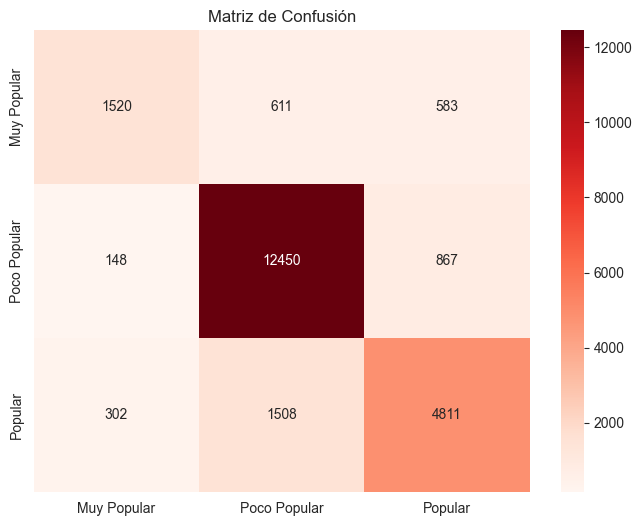

In [69]:
# Entrenamiento
rf_clf = RandomForestClassifier(
    n_estimators=100, 
    random_state=666, 
    n_jobs=-1, 
    class_weight='balanced'
)
rf_clf.fit(X_train, y_train_clf)

# Predicción y Métricas
predicciones = rf_clf.predict(X_test)
accuracy = accuracy_score(y_test_clf, predicciones)

print(f"Accuracy: {accuracy:.4f}")
print("="*80)
print(classification_report(y_test_clf, predicciones))
print("="*80)


# Matriz de Confusión
conf_matrix = confusion_matrix(y_test_clf, predicciones)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Reds', 
            xticklabels=rf_clf.classes_, yticklabels=rf_clf.classes_)
plt.title('Matriz de Confusión')
plt.show()

#### A.5. Comparación: Con vs. Sin Artista


In [70]:
# Preprocesar SIN la columna 'artists' para comparar
df_no_artist = df.drop(columns=['artists'])

# --- PREPROCESAMIENTO RÁPIDO (SIN ARTISTA) ---
# Repetimos los pasos básicos
df_subset_no = df_no_artist[features_initial[:-1]].copy() # Excluir 'artists' de la lista si estaba
if 'artists' in df_subset_no.columns:
    df_subset_no = df_subset_no.drop(columns=['artists'])

df_encoded_no = pd.get_dummies(df_subset_no, columns=['track_genre'], drop_first=True)
X_train_no, X_test_no, _, _ = train_test_split(
    df_encoded_no, y_clf, test_size=0.2, random_state=666, stratify=y_clf
)
# Limpieza final (solo popularity si quedó)
X_train_no = X_train_no.drop(columns=['popularity'], errors='ignore')
X_test_no = X_test_no.drop(columns=['popularity'], errors='ignore')

# Entrenar modelo sin artista
rf_no = RandomForestClassifier(n_estimators=50, random_state=666, n_jobs=-1, class_weight='balanced')
rf_no.fit(X_train_no, y_train_clf)

# Comparar métricas
y_pred_no = rf_no.predict(X_test_no)
y_pred_art = rf_clf.predict(X_test)

# Comparar métricas detalladas
from sklearn.metrics import precision_recall_fscore_support

# Calcular métricas para modelo SIN artista
p_no, r_no, f_no, _ = precision_recall_fscore_support(y_test_clf, y_pred_no, labels=labels, zero_division=0)
acc_no = accuracy_score(y_test_clf, y_pred_no)

# Calcular métricas para modelo CON artista
p_art, r_art, f_art, _ = precision_recall_fscore_support(y_test_clf, y_pred_art, labels=labels, zero_division=0)
acc_art = accuracy_score(y_test_clf, y_pred_art)

# Crear DataFrame comparativo

# 1. Crear datos para tabla SIN Artista
data_sin_artista = []
for i, label in enumerate(labels):
    data_sin_artista.append({
        'Clase': label,
        'Precision': p_no[i],
        'Recall': r_no[i],
        'F1-Score': f_no[i],
        'Accuracy Global': acc_no
    })

# 2. Crear datos para tabla CON Artista
data_con_artista = []
for i, label in enumerate(labels):
    data_con_artista.append({
        'Clase': label,
        'Precision': p_art[i],
        'Recall': r_art[i],
        'F1-Score': f_art[i],
        'Accuracy Global': acc_art
    })

# 3. Convertir a DataFrames
df_sin_artista = pd.DataFrame(data_sin_artista)
df_con_artista = pd.DataFrame(data_con_artista)

# 4. Mostrar las tablas
print("\n" + "="*40)
print("   RESULTADOS MODELO: SIN ARTISTA")
display(df_sin_artista.round(4))

print("\n" + "="*40)
print("   RESULTADOS MODELO: CON ARTISTA")
print("="*40)
display(df_con_artista.round(4))

# 5. Calcular y mostrar la mejora específica
idx_muy_pop = labels.index('Muy Popular')
mejora_recall = r_art[idx_muy_pop] - r_no[idx_muy_pop]
mejora_f1 = f_art[idx_muy_pop] - f_no[idx_muy_pop]

print("\n" + "-"*40)
print("   ANÁLISIS DE MEJORA (Clase 'Muy Popular')")
print("-"*40)
print(f"Mejora en Recall:   {mejora_recall:+.4f}")
print(f"Mejora en F1-Score: {mejora_f1:+.4f}")


   RESULTADOS MODELO: SIN ARTISTA


,Clase,Precision,Recall,F1-Score,Accuracy Global
0,Poco Popular,0.7788,0.9140,0.8410,0.7631
1,Popular,0.7377,0.5995,0.6614,0.7631
2,Muy Popular,0.6939,0.4134,0.5181,0.7631



   RESULTADOS MODELO: CON ARTISTA


,Clase,Precision,Recall,F1-Score,Accuracy Global
0,Poco Popular,0.8546,0.9246,0.8882,0.8237
1,Popular,0.7684,0.7266,0.7469,0.8237
2,Muy Popular,0.7716,0.5601,0.6490,0.8237



----------------------------------------
   ANÁLISIS DE MEJORA (Clase 'Muy Popular')
----------------------------------------
Mejora en Recall:   +0.1466
Mejora en F1-Score: +0.1309


#### A.6. Visualización de modificación en Umbrales.
Dado que el Umbral por defecto (0.5) no es el mejor criterio para problemas desbalanceados, se compararon las métricas globales obtenidas a partir de una evaluación para distintos valores de este:

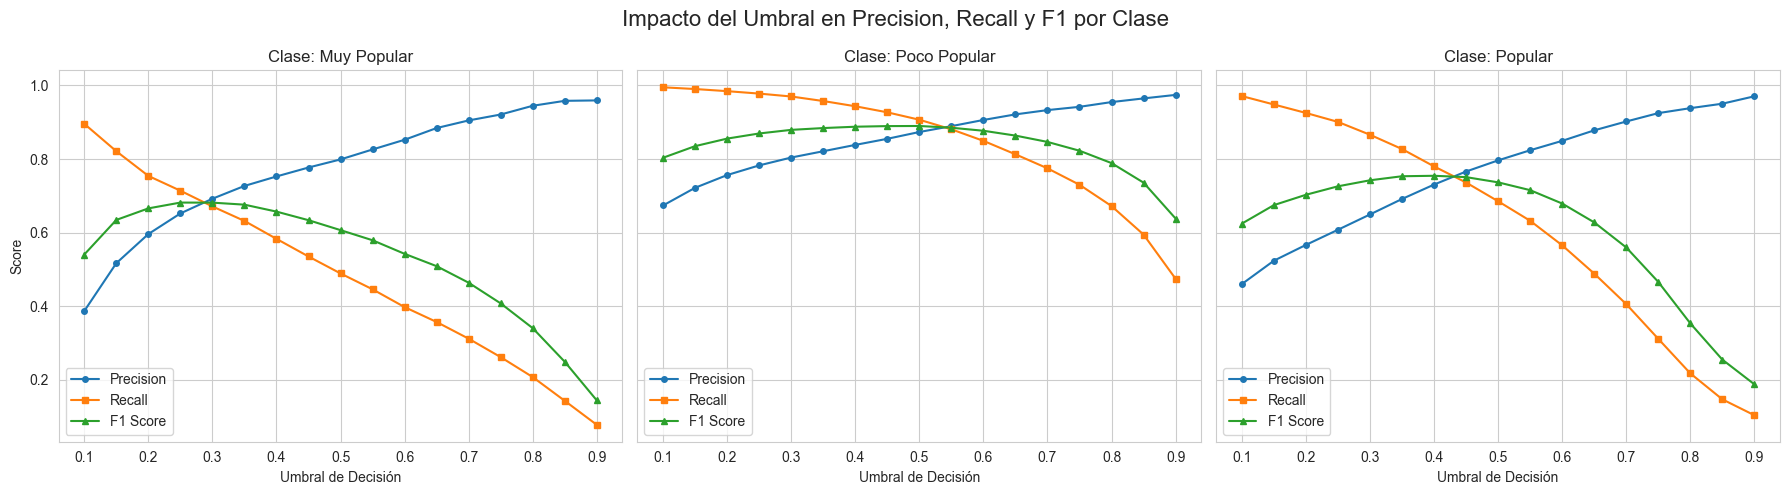

In [71]:
probs = rf_clf.predict_proba(X_test)
thresholds = np.arange(0.1, 0.95, 0.05)
clases = rf_clf.classes_

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for i, clase_objetivo in enumerate(clases):
    idx_clase = np.where(clases == clase_objetivo)[0][0]
    y_test_bin = (y_test_clf == clase_objetivo).astype(int)
    
    precisions = []
    recalls = []
    f1s = []
    
    for t in thresholds:
        preds_bin = (probs[:, idx_clase] >= t).astype(int)
        p = precision_score(y_test_bin, preds_bin, zero_division=0)
        r = recall_score(y_test_bin, preds_bin, zero_division=0)
        f = f1_score(y_test_bin, preds_bin, zero_division=0)
        
        precisions.append(p)
        recalls.append(r)
        f1s.append(f)
    
    ax = axes[i]
    ax.plot(thresholds, precisions, label='Precision', marker='o', markersize=4)
    ax.plot(thresholds, recalls, label='Recall', marker='s', markersize=4)
    ax.plot(thresholds, f1s, label='F1 Score', marker='^', markersize=4)
    
    ax.set_title(f'Clase: {clase_objetivo}')
    ax.set_xlabel('Umbral de Decisión')
    if i == 0:
        ax.set_ylabel('Score')
    ax.grid(True)
    ax.legend()

plt.suptitle('Impacto del Umbral en Precision, Recall y F1 por Clase', fontsize=16)
plt.tight_layout()
plt.show()

#### A.7. Optimización de Umbrales (Threshold Tuning)
Código para analizar cómo varía el F1-Score al cambiar el umbral de decisión y encontrar el óptimo global.

In [72]:
probs = rf_clf.predict_proba(X_test)
thresholds = np.arange(0.1, 0.95, 0.05)
clases = rf_clf.classes_
clase_objetivo = 'Muy Popular'
idx_clase_obj = np.where(clases == clase_objetivo)[0][0]
idx_otras = [i for i in range(len(clases)) if i != idx_clase_obj]

results_global = []

for t in thresholds:
    # Lógica de predicción con umbral ajustado
    y_pred_adj = []
    for i in range(len(probs)):
        if probs[i, idx_clase_obj] >= t:
            y_pred_adj.append(clase_objetivo)
        else:
            # Si no supera el umbral, elegimos la mejor entre las otras clases
            best_other_idx = idx_otras[np.argmax(probs[i, idx_otras])]
            y_pred_adj.append(clases[best_other_idx])
            
    # Calcular Macro F1 (promedio de las 3 clases)
    macro_f1 = f1_score(y_test_clf, y_pred_adj, average='macro', zero_division=0)
    
    results_global.append({
        'Umbral': t,
        'Macro F1': macro_f1
    })

# Encontrar el mejor umbral
df_global = pd.DataFrame(results_global).sort_values(by='Macro F1', ascending=False)
print(f"Mejor umbral sugerido: {df_global.iloc[0]['Umbral']:.2f}")

Mejor umbral sugerido: 0.35


### Anexo B: Código Fuente - Pregunta 2 (Clustering y Patrones Latentes)
Este anexo detalla la implementación del aprendizaje no supervisado, incluyendo la estandarización de datos, la reducción de dimensionalidad con PCA y la segmentación con K-Means.

#### B.1. Preprocesamiento y Estandarización
Es crítico escalar los datos antes de aplicar K-Means, ya que es un algoritmo basado en distancias euclidianas

In [73]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Selección de variables numéricas para el clustering
features_clustering = [
    'danceability', 'energy', 'loudness', 
    'speechiness','acousticness', 'instrumentalness',
    'liveness', 'valence', 'tempo'
]

X = df[features_clustering].copy()

# Estandarización (Media=0, Desviación=1)
scaler = StandardScaler()
features_for_clustering = ['danceability', 'energy', 'loudness', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo']
# Ensure columns exist
features_for_clustering = [c for c in features_for_clustering if c in df.columns]
X_scaled = scaler.fit_transform(df[features_for_clustering])
df_with_clusters = df.copy()

print("Datos estandarizados. Dimensiones:", X_scaled.shape)

Datos estandarizados. Dimensiones: (114000, 9)


#### B.2. Reducción de Dimensionalidad (PCA)
Aplicamos PCA para visualizar los datos multidimensionales en un plano 2D y entender la varianza explicada.

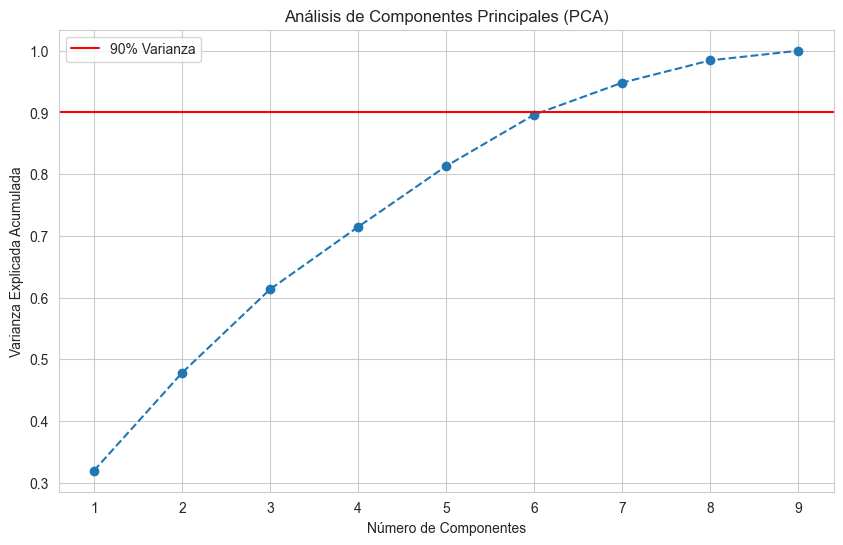

In [74]:
# Instanciamos PCA
pca = PCA()
pca.fit(X_scaled)
explained_variance = pca.explained_variance_ratio_.cumsum()

# Gráfico varianza acumulada
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(explained_variance) + 1), explained_variance, marker='o', linestyle='--')
plt.xlabel('Número de Componentes')
plt.ylabel('Varianza Explicada Acumulada')
plt.title('Análisis de Componentes Principales (PCA)')
plt.grid(True)
plt.axhline(y=0.9, color='r', linestyle='-', label='90% Varianza')
plt.legend()
plt.show()

#### B.3. Determinación de $k$ (Método del Codo y Silueta)

Código para iterar sobre distintos números de clústers y encontrar el óptimo.

Calculando K-Means para diferentes K...
K=2: Inercia=805673, Silhouette=0.2619
K=3: Inercia=715647, Silhouette=0.1653
K=4: Inercia=646331, Silhouette=0.1711
K=5: Inercia=583441, Silhouette=0.1778
K=6: Inercia=533303, Silhouette=0.1883
K=7: Inercia=484080, Silhouette=0.1967
K=8: Inercia=456282, Silhouette=0.2001
K=9: Inercia=430867, Silhouette=0.1812
K=10: Inercia=413281, Silhouette=0.1675


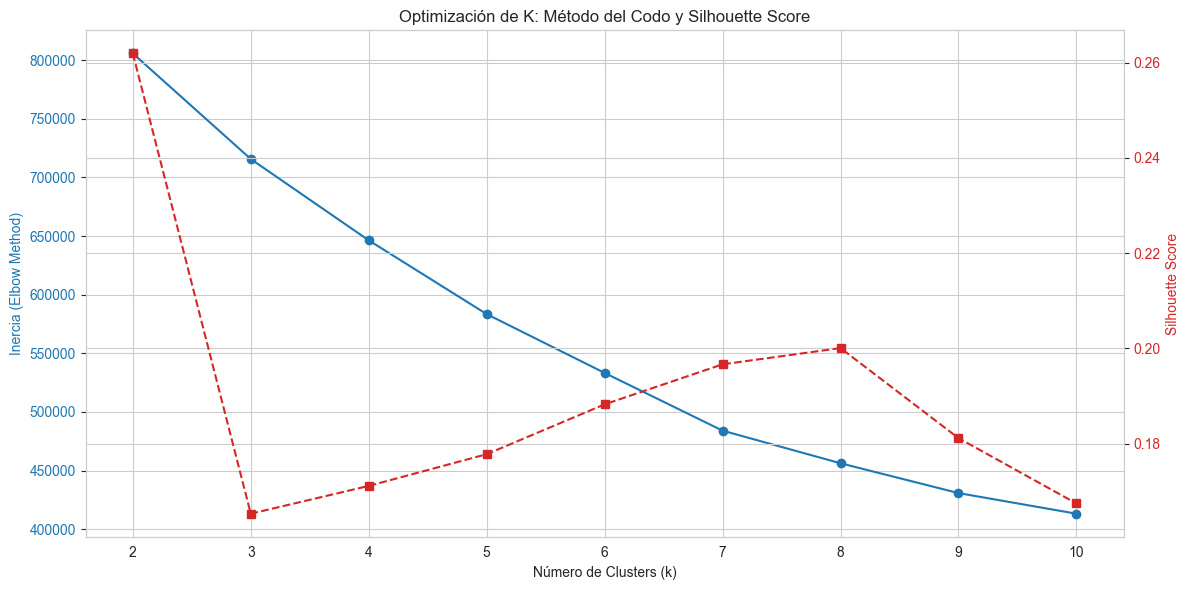

K óptimo sugerido por método del codo: 7


In [75]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

inertias = []
sil_scores = []
k_range = range(2, 11)

# Sample for silhouette if too large
if len(X_scaled) > 10000:
    idx = np.random.choice(len(X_scaled), 10000, replace=False)
    X_sample = X_scaled[idx]
else:
    X_sample = X_scaled

print('Calculando K-Means para diferentes K...')
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    
    labels = kmeans.predict(X_sample)
    score = silhouette_score(X_sample, labels)
    sil_scores.append(score)
    print(f'K={k}: Inercia={kmeans.inertia_:.0f}, Silhouette={score:.4f}')

components_df = inertias, sil_scores
# --- Visualización Combinada: Método del Codo y Silhouette ---
fig, ax1 = plt.subplots(figsize=(12, 6))

color = 'tab:blue'
ax1.set_xlabel('Número de Clusters (k)')
ax1.set_ylabel('Inercia (Elbow Method)', color=color)
ax1.plot(k_range, inertias, 'o-', color=color, label='Inercia')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, axis='x')

ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Silhouette Score', color=color)
ax2.plot(k_range, sil_scores, 's--', color=color, label='Silhouette Score')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Optimización de K: Método del Codo y Silhouette Score')
fig.tight_layout()
plt.show()

# Función Auxiliar para calcular el K óptimo
def calculate_elbow_point(k_range, inertias):
    # Convertir a arrays
    x = np.array(list(k_range))
    y = np.array(inertias)
    
    # 1. Normalizar los datos entre 0 y 1 para que las escalas no afecten el cálculo geométrico
    x_norm = (x - x.min()) / (x.max() - x.min())
    y_norm = (y - y.min()) / (y.max() - y.min())
    
    # 2. Crear coordenadas normalizadas
    all_coords = np.vstack((x_norm, y_norm)).T
    
    # 3. Vector de la línea (del primer al último punto)
    first_point = all_coords[0]
    line_vec = all_coords[-1] - all_coords[0]
    line_vec_norm = line_vec / np.sqrt(np.sum(line_vec**2))
    
    # 4. Calcular distancia de cada punto a la línea
    vec_from_first = all_coords - first_point
    scalar_product = np.sum(vec_from_first * line_vec_norm, axis=1)
    vec_from_first_parallel = scalar_product[:, np.newaxis] * line_vec_norm
    vec_to_line = vec_from_first - vec_from_first_parallel
    dist_to_line = np.sqrt(np.sum(vec_to_line**2, axis=1))
    
    # 5. Obtener el índice del punto más lejano
    idx_of_best_point = np.argmax(dist_to_line)
    
    return k_range[idx_of_best_point]

# Calcular K óptimo automático
optimal_k_elbow = calculate_elbow_point(k_range, inertia)

print(f'K óptimo sugerido por método del codo: {optimal_k_elbow}')

#### B.4. Entrenamiento del Modelo K-Means
Entrenamiento final con el $k$ seleccionado (en este caso, $k=7$) y asignación de etiquetas.

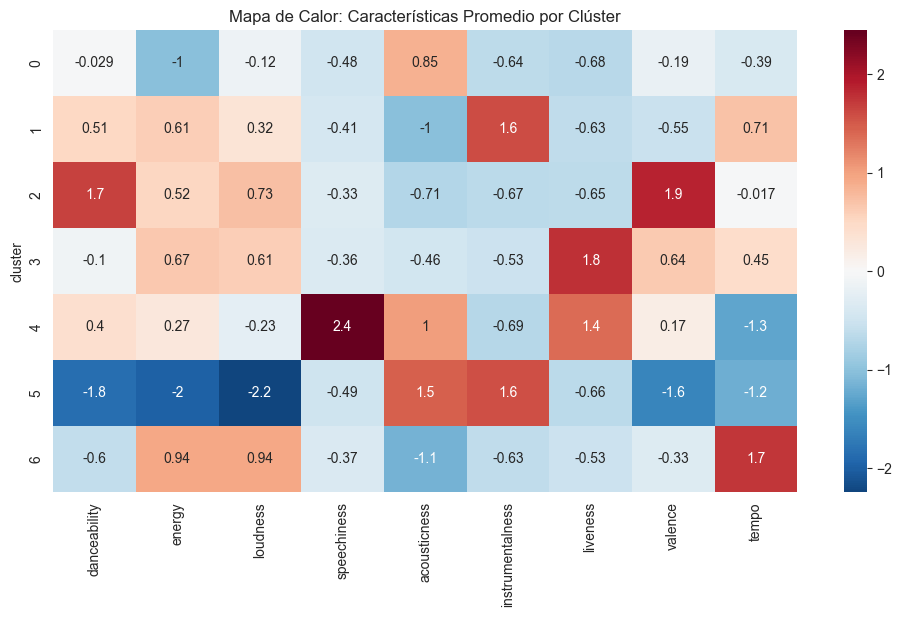

In [76]:
# Entrenar K-Means con k=7 (según análisis previo)
k_optimo = 7
kmeans_final = KMeans(n_clusters=k_optimo, random_state=666, n_init=10)
cluster_labels = kmeans_final.fit_predict(X_scaled)

# Asignar etiquetas al dataframe original y al de PCA
df['cluster'] = cluster_labels
df_pca['cluster'] = cluster_labels

# Análisis de Centroides (Perfilamiento)
# Calculamos el promedio de cada característica por clúster
cluster_means = df.groupby('cluster')[features_clustering].mean()

# Normalizamos los centros para visualizarlos mejor en un Heatmap (opcional)
scaler_means = StandardScaler()
cluster_means_scaled = pd.DataFrame(
    scaler_means.fit_transform(cluster_means), 
    columns=cluster_means.columns,
    index=cluster_means.index
)

plt.figure(figsize=(12, 6))
sns.heatmap(cluster_means_scaled, annot=True, cmap='RdBu_r', center=0)
plt.title('Mapa de Calor: Características Promedio por Clúster')
plt.show()

#### B.5. Visualización de Clústers en 2D
Gráfico de dispersión utilizando los componentes del PCA para ver la separación de los grupos.

Generando visualización t-SNE...


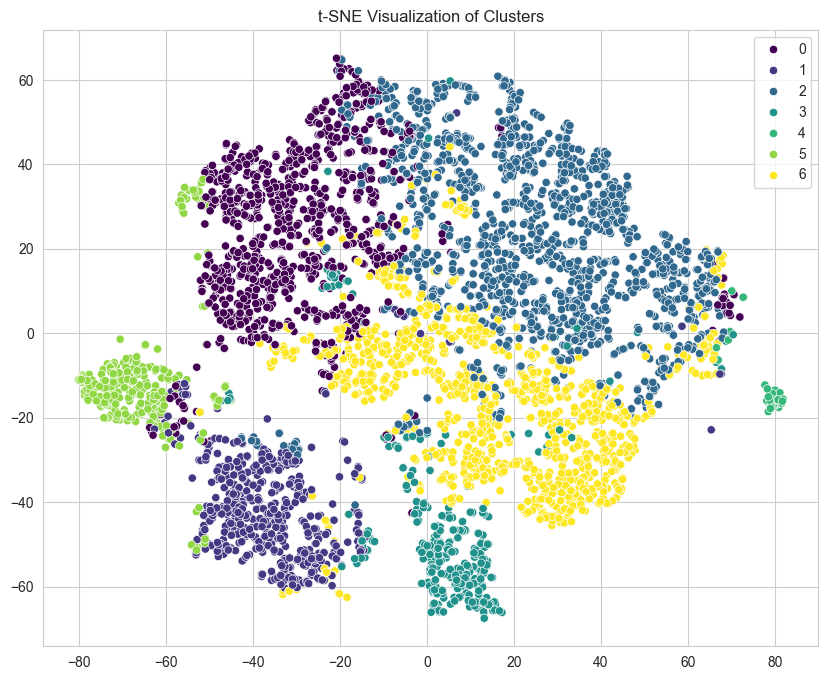

In [77]:
def plot_tsne(X, labels):
    print('Generando visualización t-SNE...')
    # Usar una muestra si el dataset es muy grande para t-SNE
    if len(X) > 5000:
        idx = np.random.choice(len(X), 5000, replace=False)
        X_sample = X[idx]
        labels_sample = labels[idx]
    else:
        X_sample = X
        labels_sample = labels
        
    tsne = TSNE(n_components=2, random_state=42)
    X_embedded = tsne.fit_transform(X_sample)
    
    plt.figure(figsize=(10, 8))
    sns.scatterplot(x=X_embedded[:, 0], y=X_embedded[:, 1], hue=labels_sample, palette='viridis', legend='full')
    plt.title('t-SNE Visualization of Clusters')
    plt.show()
    
plot_tsne(X_scaled, cluster_labels)

#### B.6. Generación de Perfiles
Gráfico de barras con distribución de los 10 géneros más presentes por cluster.

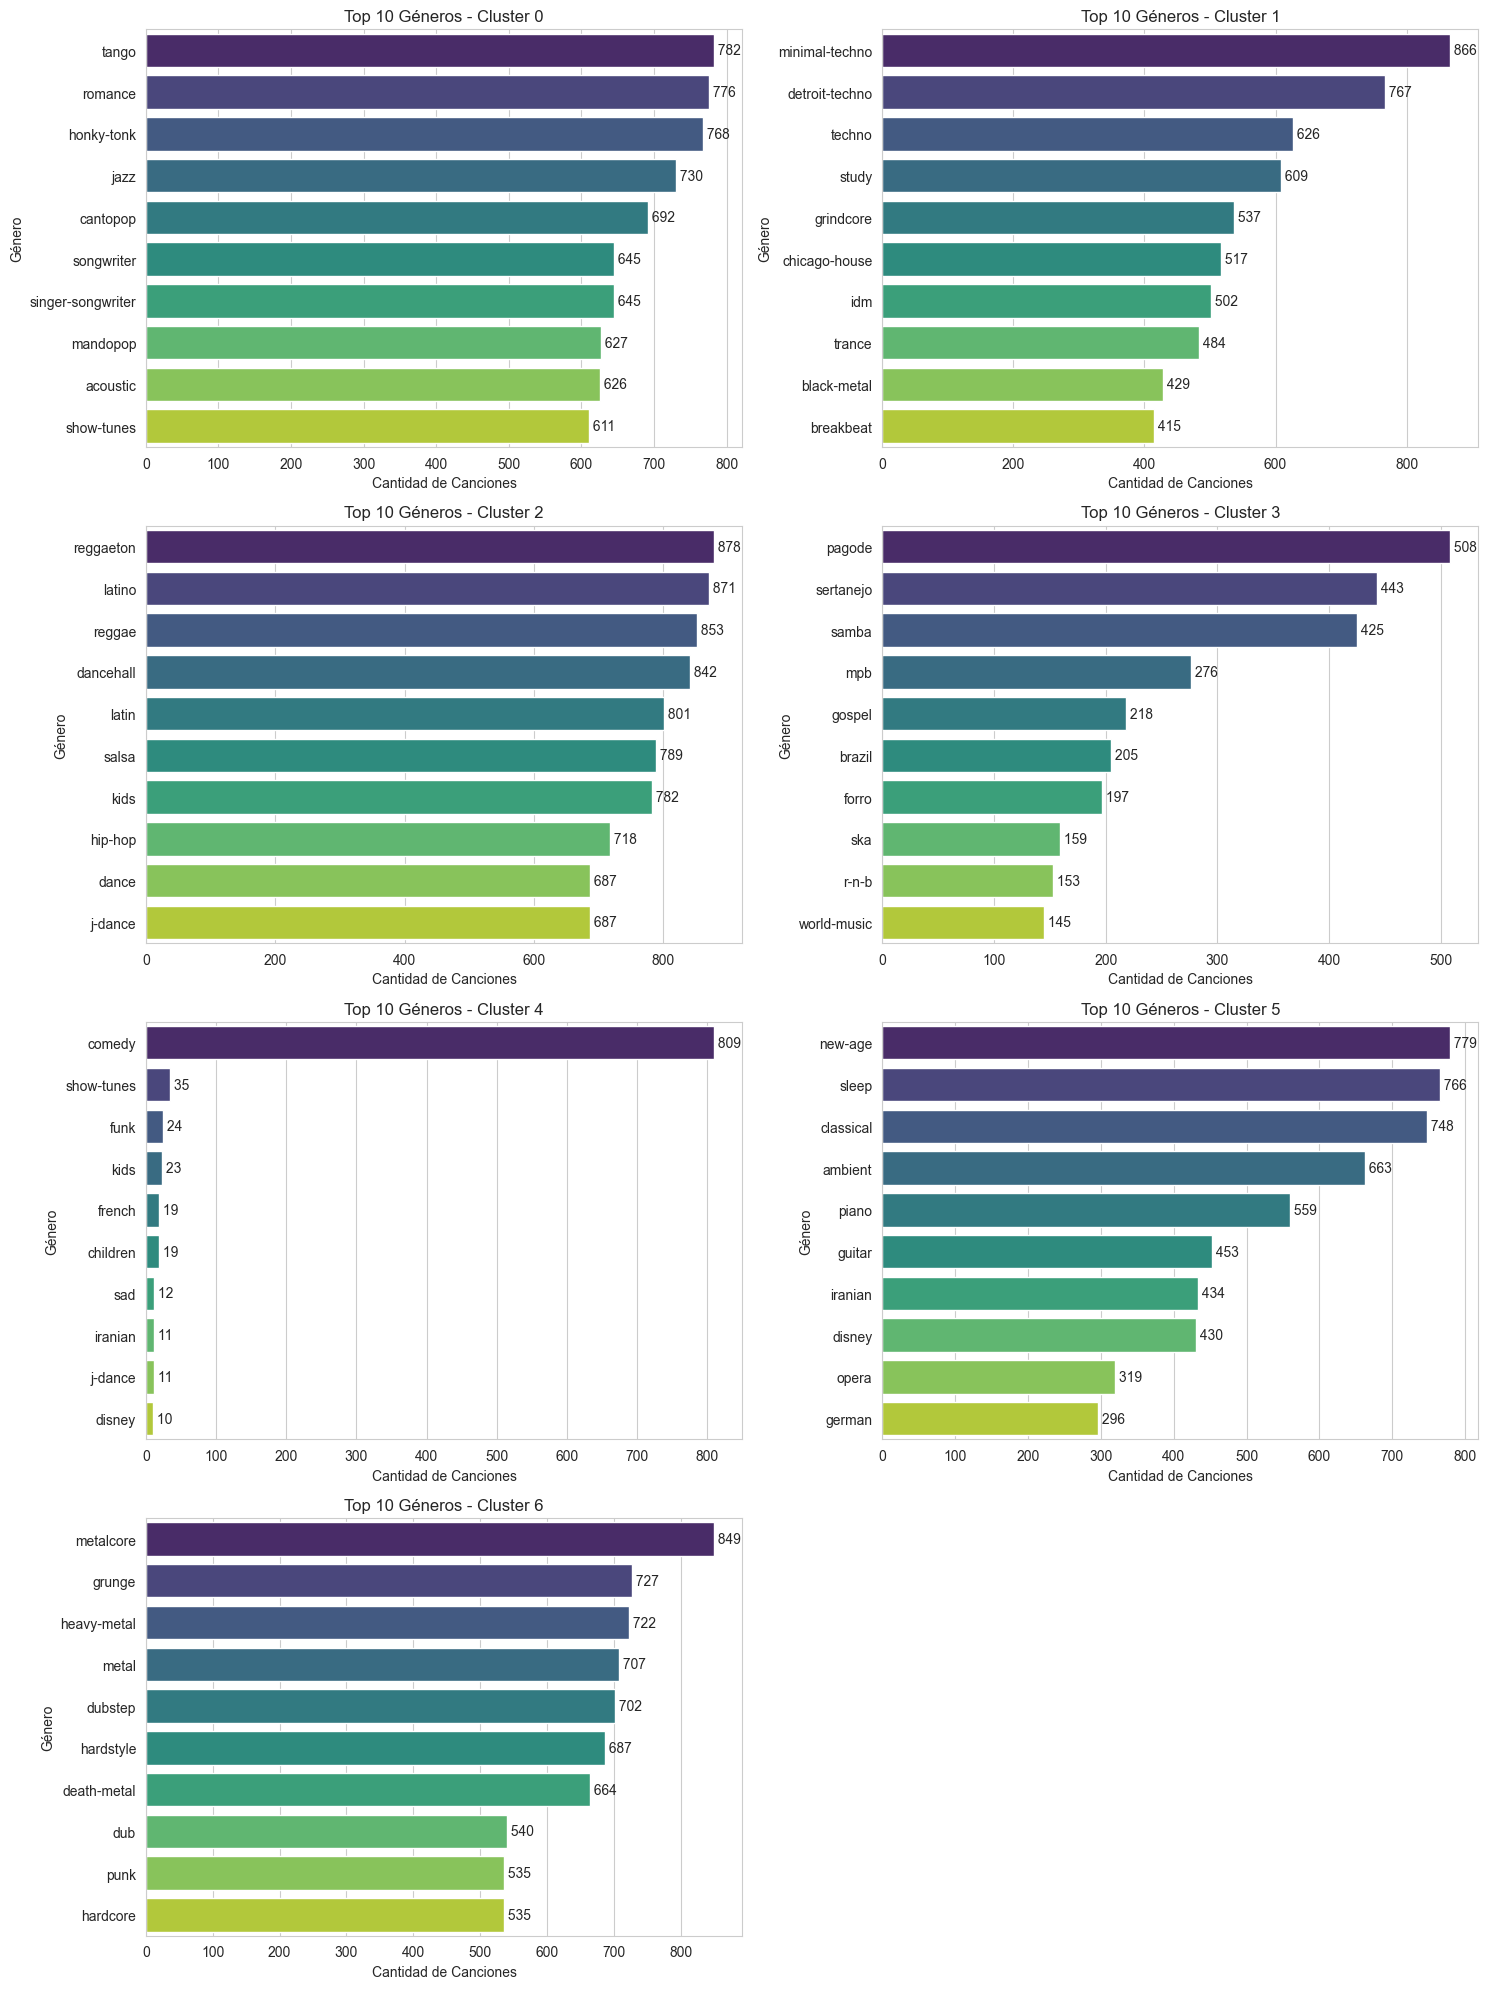

In [78]:
df['cluster'] = cluster_labels
df_with_clusters, clusters = df, cluster_labels

# Configuración de los gráficos
n_clusters = len(df_with_clusters['cluster'].unique())
n_cols = 2
n_rows = (n_clusters + n_cols - 1) // n_cols

plt.figure(figsize=(15, 5 * n_rows))

# Asumiendo que la columna de género se llama 'track_genre'.
# Si tiene otro nombre (ej. 'genre'), cámbialo aquí:
genre_col = 'track_genre'

for i in range(n_clusters):
    plt.subplot(n_rows, n_cols, i + 1)
    
    # Filtrar datos por cluster
    cluster_data = df_with_clusters[df_with_clusters['cluster'] == i]
    
    # Contar top 10 géneros
    top_genres = cluster_data[genre_col].value_counts().head(10)
    
    # Crear gráfico de barras
    sns.barplot(
        x=top_genres.values, 
        y=top_genres.index, 
        hue=top_genres.index,
        palette='viridis',
        legend=False
    )
    
    # Añadir etiquetas de conteo al final de las barras
    for index, value in enumerate(top_genres.values):
        plt.text(value, index, f' {value}', va='center')

    plt.title(f'Top 10 Géneros - Cluster {i}')
    plt.xlabel('Cantidad de Canciones')
    plt.ylabel('Género')

plt.tight_layout()
plt.show()

### Anexo C: Código Fuente - Pregunta 3 (Clasificación de Géneros)
Este anexo presenta la implementación utilizada para la selección de características y el posterior entrenamiento para los modelos de Random Forest y XGBoost.

#### C.1 Carga y Preprocesamiento de Datos
Preprocesamiento del dataset, codificación de la variable objetivo (clusters) y división estratificada de datos.

In [79]:

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedKFold
from sklearn.feature_selection import SelectKBest, mutual_info_classif

# Carga del dataset con clusters pre-calculados
spotifySongDS = pd.read_csv('dataset_clusters_10.csv')

# Preparación de datos para clasificación por clustering
classificationData = spotifySongDS.copy()

# Asignación de etiqueta representativa por mayoría de voto en el cluster
topgenre = classificationData.groupby("cluster")["track_genre"].agg(lambda x: x.value_counts().idxmax())
print(f"Clases utilizadas (Super-géneros): {topgenre}")

# Filtrado de datos
classificationData = classificationData[classificationData["track_genre"].isin(topgenre)]

# Definición de Features (X) y Target (y)
c = ['popularity', 'duration_ms', 'explicit', 'danceability', "energy",
     "key", "loudness", "mode", "speechiness", "acousticness", 
     'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature']

X_clasification = classificationData[c]
y_clasification_str = np.squeeze(classificationData[["track_genre"]])

# Label Encoding
le = LabelEncoder()
le.fit(y_clasification_str)
y_clasification = le.transform(y_clasification_str)

# Scaling
scalerC = StandardScaler()
X_clasification_scaled = scalerC.fit_transform(X_clasification)

# Split (Train/Val/Test)
X_train, X_vt, y_train, y_vt = train_test_split(
    X_clasification_scaled, y_clasification, test_size=0.4, random_state=0, stratify=y_clasification
)
X_val, X_test, y_val, y_test = train_test_split(X_vt, y_vt, test_size=0.5, random_state=0)

Clases utilizadas (Super-géneros): cluster
0            pagode
1           romance
2        honky-tonk
3    minimal-techno
4         reggaeton
5         hardstyle
6           j-dance
7            comedy
8           new-age
9         metalcore
Name: track_genre, dtype: object


#### C.2 Selección de Características

Selección de las variables más relevantes para la clasificación utilizando la técnica SelectKBest e Información Mutua.

In [80]:
# Selección de las 11 mejores características
kBestModel = SelectKBest(mutual_info_classif, k=11)
kBestModel.fit(X_train, y_train)

X_train_k = kBestModel.transform(X_train)
X_val_k = kBestModel.transform(X_val)

# Concatenación para GridSearch (Train + Val)
X = np.concatenate((X_train_k, X_val_k))
Y = np.concatenate((y_train, y_val))

print("Features seleccionadas:", kBestModel.get_feature_names_out(input_features=c))

Features seleccionadas: ['popularity' 'duration_ms' 'danceability' 'energy' 'loudness'
 'speechiness' 'acousticness' 'instrumentalness' 'liveness' 'valence'
 'tempo']


#### C.3 Entrenamiento y Evaluación de Random Forest

Entrenamiento, ajuste de hiperparámetros y evaluación del modelo Random Forest Classifier para la predicción de clusters.

Resultados Random Forest:
              precision    recall  f1-score   support

           0      0.988     0.852     0.915       196
           1      0.843     0.883     0.862       188
           2      0.939     0.948     0.944       194
           3      0.768     0.798     0.783       203
           4      0.918     0.932     0.925       192
           5      0.919     0.955     0.937       202
           6      0.927     0.922     0.925       206
           7      0.900     0.975     0.936       202
           8      0.908     0.874     0.890       214
           9      0.984     0.931     0.957       203

    accuracy                          0.907      2000
   macro avg      0.909     0.907     0.907      2000
weighted avg      0.909     0.907     0.907      2000



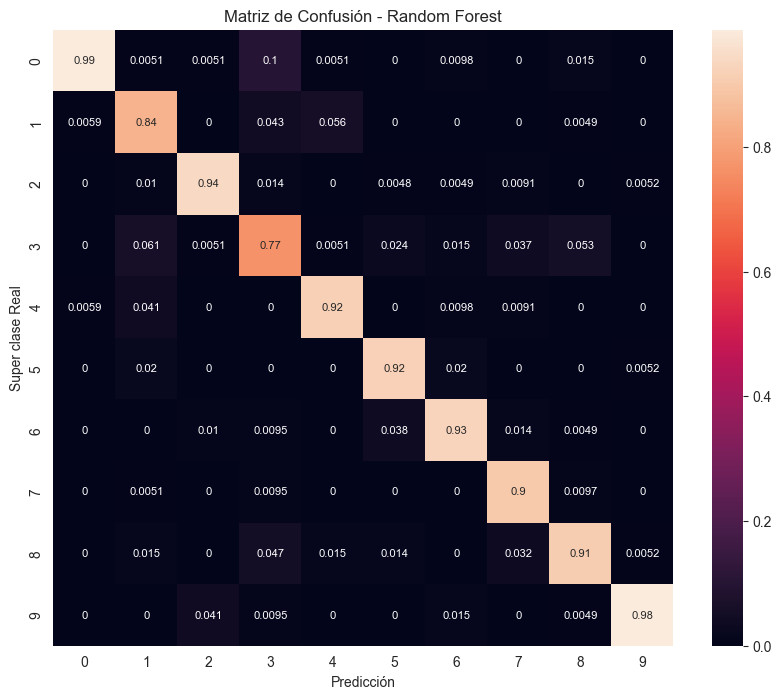

In [81]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración del GridSearch
rf = RandomForestClassifier(random_state=0)
hiperparam_Random_Forest = {
    "max_depth": [None, 5, 15, 20, 25, 35], 
    "n_estimators": [300, 400, 450, 500, 600]
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

# Búsqueda de hiperparámetros (comentado para evitar ejecución larga en reporte, se usan los mejores hallados)
# grid_Random_Forest = GridSearchCV(rf, hiperparam_Random_Forest, cv=cv, verbose=5)
# grid_Random_Forest.fit(X, Y)

# Modelo Definitivo (Mejores params: max_depth=15, n_estimators=300)
rfFinal = RandomForestClassifier(max_depth=15, n_estimators=300, random_state=0) 
rfFinal.fit(X_train_k, y_train)
rf_val_pred = rfFinal.predict(X_val_k)

# Reporte
print("Resultados Random Forest:")
print(classification_report(y_val, rf_val_pred, digits=3))

# Matriz de Confusión
plt.figure(figsize=(10, 8))
sns.heatmap(confusion_matrix(y_val, rf_val_pred, normalize="pred"), annot=True, fmt=".2g", annot_kws={"size": 8})
plt.ylabel('Super clase Real')
plt.xlabel('Predicción')
plt.title('Matriz de Confusión - Random Forest')
plt.show()

#### C.4 Entrenamiento y Evaluación de XGBoost

Implementación del modelo XGBoost, optimización mediante GridSearch y análisis de su matriz de confusión final.

Resultados XGBoost:
              precision    recall  f1-score   support

           0      0.946     0.893     0.919       196
           1      0.884     0.888     0.886       188
           2      0.969     0.954     0.961       194
           3      0.836     0.828     0.832       203
           4      0.925     0.964     0.944       192
           5      0.938     0.970     0.954       202
           6      0.925     0.961     0.943       206
           7      0.947     0.975     0.961       202
           8      0.937     0.902     0.919       214
           9      0.975     0.946     0.960       203

    accuracy                          0.928      2000
   macro avg      0.928     0.928     0.928      2000
weighted avg      0.928     0.928     0.928      2000



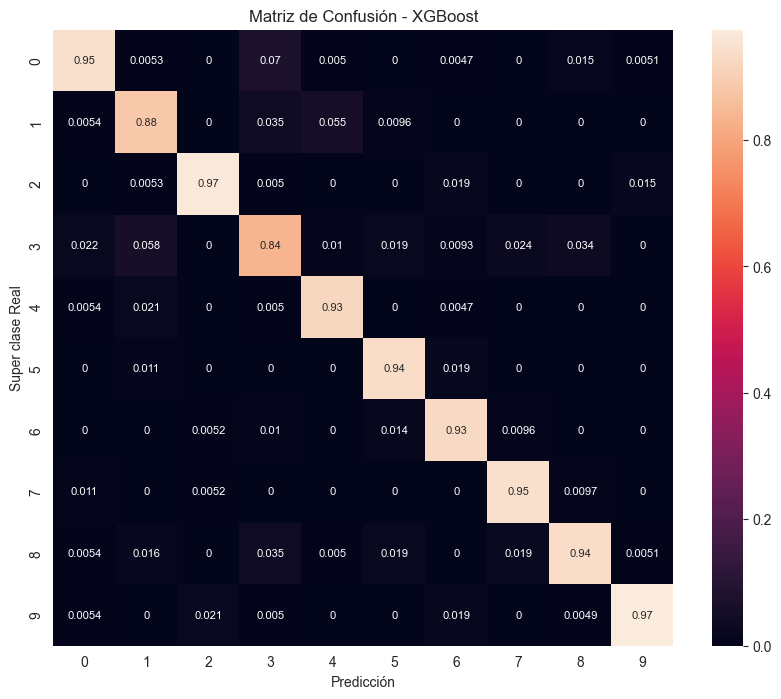

In [82]:
from xgboost import XGBClassifier

# Configuración del modelo base
xgb = XGBClassifier(objective="multi:softmax", num_class=10, tree_method="hist")

# GridSearch (Referencial)
hiperparam_XGB = {
    "n_estimators": [200, 500],
    "max_depth": [4, 6, 8],
    "learning_rate": [0.1, 0.05],
    "subsample": [0.8],
    "colsample_bytree": [0.8]
}

# Modelo Definitivo (Mejores params hallados)
xgbFinal = XGBClassifier(
    objective="multi:softmax", num_class=10, tree_method="hist",
    colsample_bytree=0.8, learning_rate=0.1, max_depth=6, n_estimators=200, subsample=0.8
)
xgbFinal.fit(X_train_k, y_train)
xgb_val_pred = xgbFinal.predict(X_val_k)

# Reporte
print("Resultados XGBoost:")
print(classification_report(y_val, xgb_val_pred, digits=3))

# Matriz de Confusión
plt.figure(figsize=(10, 8))
sns.heatmap(confusion_matrix(y_val, xgb_val_pred, normalize="pred"), annot=True, fmt=".2g", annot_kws={"size": 8})
plt.ylabel('Super clase Real')
plt.xlabel('Predicción')
plt.title('Matriz de Confusión - XGBoost')
plt.show()